# Choices13k: Predicting Choice Behavior in Risky Gambles

## Introduction

This notebook analyzes the [**Choices13k**](https://github.com/jcpeterson/choices13k) dataset, which contains human choices between pairs of lotteries (gambles) with feedback. The goal is to predict the **choice rate** (`bRate`: proportion of times option B was chosen) from problem and gamble features, using the problem definitions in `c13k_problems.json` and the selection data in `c13k_selections.csv`.

The analysis proceeds as follows:

1. **Data fetching and loading** — Download or load the selections CSV and problems JSON from the Choices13k repository, then merge them into a single dataframe.
2. **Data quality** — Check for duplicate problems and inspect feedback patterns.
3. **Exploratory data analysis** — Summarize the merged data, inspect the target (`bRate`), and examine correlations with the target.
4. **Feature engineering** — Derive numeric features from the gamble structure (e.g. expected value, standard deviation, extreme outcomes, BEAST-style features).
5. **Modeling** — Train and compare multiple regressors (Ridge, Random Forest, SVR, Gradient Boosting, XGBoost, LightGBM, etc.) with hyperparameter search and evaluate on held-out test data.

We first have to download the required packages

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.7 MB/s eta 0:00:00


In [2]:
import requests
import os
from urllib.parse import urlparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import mean_squared_error
import optuna

## 1. Fetching the data

We download the selections and problem files from the Choices13k repository if they are not already present locally.


In [3]:
def download_file(url, save_path=None):
    try:
        response = requests.get(url, stream=True, timeout=15)
        response.raise_for_status()

        if save_path is None:
            filename = os.path.basename(urlparse(url).path) or "downloaded_file"
            save_path = os.path.join(os.getcwd(), filename)

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        downloaded_size = 0
        with open(save_path, 'wb') as file:
            for data in response.iter_content(block_size):
                file.write(data)
                downloaded_size += len(data)
                if total_size:
                    percent = (downloaded_size / total_size) * 100
                    print(f"\rDownloading: {percent:.2f}%", end="")

        print(f"\nDownload complete: {save_path}")

    except requests.exceptions.MissingSchema:
        print("Invalid URL format.")
    except requests.exceptions.ConnectionError:
        print("Connection error. Check your internet connection.")
    except requests.exceptions.Timeout:
        print("Request timed out.")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


We download the 2 files. `c13k_problems.json` contains the problem descriptions and `c13k_selections.csv` contains additional info about the gambles and the target variable,`brate`.

In [4]:
BASE_URL = 'https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main'

csv_url = f'{BASE_URL}/c13k_selections.csv'
json_url = f'{BASE_URL}/c13k_problems.json'

if not os.path.exists('c13k_selections.csv'):
    download_file(csv_url)
if not os.path.exists('c13k_problems.json'):
    download_file(json_url)

Downloading: 375.17%
Download complete: /content/c13k_selections.csv
Downloading: 629.01%
Download complete: /content/c13k_problems.json


We then validate that the json is correct.

In [5]:
def validate_json_file(path: str) -> bool:
    try:
        with open(path, "r", encoding="utf-8") as f:
            json.load(f)
        print("JSON is valid")
        return True
    except json.JSONDecodeError as e:
        print("Invalid JSON:", e)
        return False

validate_json_file("c13k_problems.json")


JSON is valid


True

### 1.1 Loading and merging the data

We load the selections CSV and the problems JSON, then join them on the problem identifier to obtain a single dataframe with both choice outcomes and gamble structure.

In [6]:
df = pd.read_csv('c13k_selections.csv')
df.head()
df.isnull().sum()

,0
Problem,0
Feedback,0
n,0
Block,0
Ha,0
pHa,0
La,0
Hb,0
pHb,0
Lb,0


In [7]:
len(df)

14568

In [8]:
problems = pd.read_json("c13k_problems.json", orient='index')
problems

,B,A
0,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...
14563,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


In [9]:
selections = pd.read_csv('c13k_selections.csv')

with pd.option_context('display.max_columns', None):
    display(selections)

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476


In [10]:
selections.columns = [col.lower() for col in selections.columns]

In [11]:
df_full = selections.join(problems, how='left')

In [12]:
with pd.option_context('display.max_columns', None):
    display(df_full)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


### Column descriptions

| Column | Type | Description |
|--------|------|-------------|
| **problem** | Integer | A unique internal problem ID. |
| **n** | Integer | The number of subjects run on the current problem. |
| **feedback** | Boolean | Whether the participants were given feedback about the reward they received and missed out on after making their selection. |
| **brate** | Float | **Target.** The frequency with which subjects selected Gamble B on the current problem. |
| **ha** | Integer | The first outcome of gamble A. |
| **pha** | Float | The probability of Ha in gamble A. |
| **la** | Integer | The second outcome of gamble A (occurs with probability 1−pHa). |
| **hb** | Integer | The expected value of the lottery in gamble B. |
| **phb** | Float | The probability of the lottery in gamble B. |
| **lb** | Float | The non-lottery outcome in gamble B (occurs with probability 1−pHb). |
| **lotshapeb** | {0, 1, 2, 3} | Shape of the lottery distribution for gamble B: 1 = symmetric around its mean, 2 = right-skewed, 3 = left-skewed, 0 = undefined (e.g. if LotNumB = 1). |
| **lotnumb** | Integer | The number of possible outcomes in the gamble B lottery. |
| **amb** | Boolean | Whether the decision maker could see the probabilities of the outcomes in Gamble B. 1 = no information (ambiguity), 0 = complete information. |
| **corr** | {-1, 0, 1} | Whether there is a correlation (negative, zero, or positive) between the payoffs of the two gambles. |
| **block** | {1, 2, 3, 4, 5} | The block ID for the current problem. For no feedback, Block is always 1; otherwise sampled uniformly from {2, 3, 4, 5}. |
| **brate_std** | Float | Empirical standard deviation of the choice proportion (not in official schema). |
| **A** | list | Full gamble A: list of `[outcome, probability]` pairs (from problems JSON). |
| **B** | list | Full gamble B: list of `[outcome, probability]` pairs (from problems JSON). |

We now have a unified dataset containing both the gambles descriptions and the choices.

## 2. Data quality and duplicates

We check for duplicate problem IDs and inspect the distribution of feedback (e.g. choice consistency across blocks).

In [13]:
counts = df_full.groupby('problem').size().reset_index(name='count').sort_values(by="count", ascending=False)

In [14]:
idx = counts.loc[counts["count"] > 1, "problem"].tolist()


In [15]:
df_full.loc[df_full['problem'].isin(idx),:]

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.866667,0.351866,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.962500,0.150000,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
8,8,False,15,1,27,1.00,27,89,0.50,-24,0,1,False,0,0.453333,0.403320,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
9,8,True,16,2,27,1.00,27,89,0.50,-24,0,1,False,0,0.612500,0.434933,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
11,10,False,15,1,1,1.00,1,59,0.05,0,0,1,True,0,0.773333,0.406143,"[[0.9500000000000001, 0.0], [0.05, 59.0]]","[[1.0, 1.0], [0.0, 1.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8293,6734,True,18,5,77,0.01,30,116,0.40,-12,2,5,True,0,0.688889,0.292834,"[[0.6000000000000001, -12.0], [0.2, 112.0], [0...","[[0.01, 77.0], [0.99, 30.0]]"
8296,6737,False,16,1,26,1.00,26,41,0.60,7,0,1,False,0,0.450000,0.287518,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8297,6737,True,16,3,26,1.00,26,41,0.60,7,0,1,False,0,0.600000,0.309839,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8299,6739,False,16,1,-1,0.95,-4,10,0.75,-17,2,3,False,0,0.787500,0.247319,"[[0.25, -17.0], [0.375, 8.0], [0.1875, 10.0], ...","[[0.9500000000000001, -1.0], [0.05, -4.0]]"


We can see that while the dataset reports 13,006 risky choice problems, our dataset has 3,124 additional rows.

In [16]:
df_full['feedback'].value_counts()

,count
feedback,
True,12188
False,2380


In [17]:
count = (
    df_full
    .groupby("problem")["feedback"]
    .nunique()
    .eq(2)
    .sum()
)

print(count)


1562


The reason behind the duplicate problem ids, is that in some cases some subjects were given feedback before their decision and therefore, one column is for subjects with feedback and one for subjects without feedback.

## 3. Exploratory data analysis

We first need to investigate the dataset, inspect the target variable `bRate`, and the correlations of the features with `bRate`.

First 5 rows of df:


,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
problem,14568.0,NaN,NaN,NaN,6163.333677,3733.123605,1.0,2961.75,5888.5,9364.25,13006.0
feedback,14568,2,True,12188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,14568.0,NaN,NaN,NaN,16.670717,2.588231,15.0,16.0,16.0,17.0,33.0
block,14568.0,NaN,NaN,NaN,3.099053,1.379569,1.0,2.0,3.0,4.0,5.0
ha,14568.0,NaN,NaN,NaN,22.014072,24.076396,-10.0,5.0,18.0,29.0,118.0
pha,14568.0,NaN,NaN,NaN,0.747192,0.351998,0.01,0.5,1.0,1.0,1.0
la,14568.0,NaN,NaN,NaN,3.813152,16.406765,-50.0,-6.0,5.0,17.0,30.0
hb,14568.0,NaN,NaN,NaN,35.583677,27.659754,-18.0,15.0,30.0,52.0,119.0
phb,14568.0,NaN,NaN,NaN,0.444946,0.325977,0.01,0.2,0.4,0.75,1.0
lb,14568.0,NaN,NaN,NaN,-4.147721,18.270573,-50.0,-16.0,-3.0,9.0,41.0



Missing values per column:
problem      0
feedback     0
n            0
block        0
ha           0
pha          0
la           0
hb           0
phb          0
lb           0
lotshapeb    0
lotnumb      0
amb          0
corr         0
brate        0
brate_std    0
B            0
A            0
dtype: int64


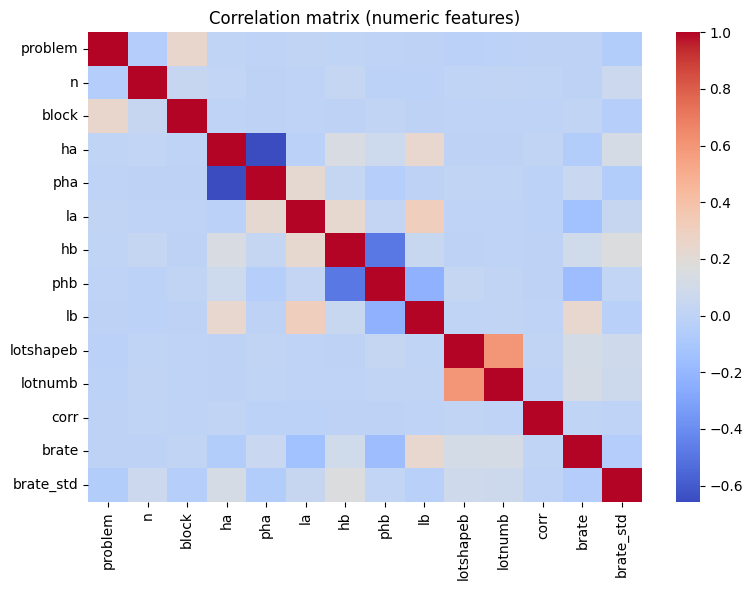

In [18]:
# Basic exploration of the dataset

from IPython.display import display
print("First 5 rows of df:")
display(df_full.head())

# Summary statistics (numeric and categorical)
print("\nSummary statistics:")
display(df_full.describe(include="all").T)

# Missing values per column
print("\nMissing values per column:")
print(df_full.isnull().sum())

# Distribution of the main rate column (if present)
if "bRate" in df_full.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_full["bRate"], kde=True)
    plt.title("Distribution of bRate")
    plt.xlabel("bRate")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Correlation matrix for numeric features
numeric_df = df_full.select_dtypes(include=["number"])
if not numeric_df.empty:
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.show()

Correlation of each numeric feature with brate (sorted):


,corr_with_bRate
lb,0.238497
lotnumb,0.122896
lotshapeb,0.112797
hb,0.092437
amb,0.087488
pha,0.053659
block,0.015038
corr,0.005025
feedback,0.003050
problem,-0.005596


/tmp/ipython-input-2802929659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_brate.values, y=corr_with_brate.index, palette="viridis")


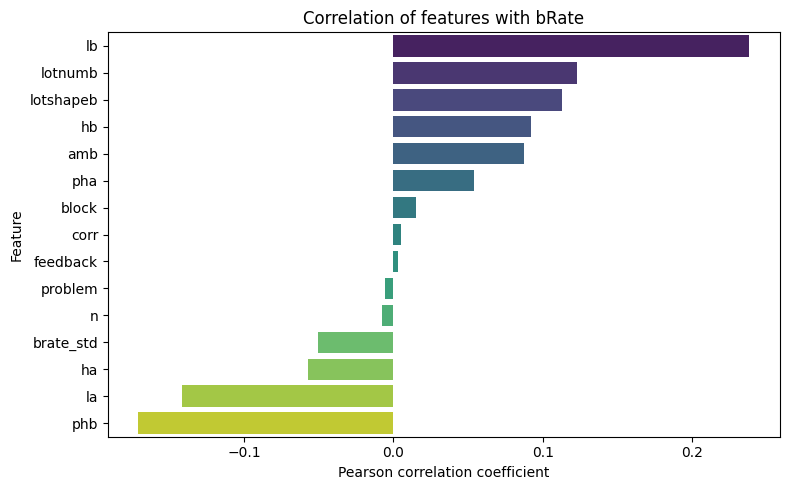

In [19]:
# Correlation of all numeric features with bRate

corr_matrix = df_full.corr(numeric_only=True)
corr_with_brate = corr_matrix["brate"].drop(labels=["brate"], errors="ignore").sort_values(ascending=False)

print("Correlation of each numeric feature with brate (sorted):")
display(corr_with_brate.to_frame(name="corr_with_bRate"))

# Bar plot of correlations
plt.figure(figsize=(8, 5))
sns.barplot(x=corr_with_brate.values, y=corr_with_brate.index, palette="viridis")
plt.title("Correlation of features with bRate")
plt.xlabel("Pearson correlation coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 4. Feature engineering

We build numeric features from the gamble lists: expected value and standard deviation, extreme-outcome flags, probability of positive payoff, and psychological features (e.g. probability that A beats B, regret, worst-case comparison).

In [20]:
# Step 1: Basic numeric cleaning (round all numeric columns)

numeric_cols = df_full.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    # Keep 'problem' as an identifier, don't round it
    if col != "problem":
        df_full[col] = df_full[col].round(2)

In [21]:
# Step 2: Helper functions for gamble lists and basic EV/std features

import ast
import numpy as np

def _ensure_gamble_list(gamble_list):
    """Ensure we always work with a list[(p, r)], not a JSON string."""
    if isinstance(gamble_list, str):
        return ast.literal_eval(gamble_list)
    return gamble_list

def round_gamble_column(gamble_list, decimals=2):
    """Round probabilities and rewards to a fixed number of decimals."""
    gl = _ensure_gamble_list(gamble_list)
    return [(round(p, decimals), round(r, decimals)) for p, r in gl]

def calculate_gamble_stats(gamble_list):
    """
    Compute expected value (EV) and standard deviation for a gamble.

    gamble_list: list of (probability, reward) tuples
    returns: (ev, std_dev)
    """
    gl = _ensure_gamble_list(gamble_list)
    probs = [x[0] for x in gl]
    rewards = [x[1] for x in gl]

    ev = sum(p * r for p, r in zip(probs, rewards))
    variance = sum(p * (r - ev) ** 2 for p, r in zip(probs, rewards))
    std_dev = np.sqrt(variance)

    return round(ev, 2), round(std_dev, 2)

# Apply rounding to raw gamble columns
df_full["A"] = df_full["A"].apply(round_gamble_column)
df_full["B"] = df_full["B"].apply(round_gamble_column)

# Compute EV and std for each option
df_full["A_ev"], df_full["A_std"] = zip(*df_full["A"].apply(calculate_gamble_stats))
df_full["B_ev"], df_full["B_std"] = zip(*df_full["B"].apply(calculate_gamble_stats))

# Basic risk features
df_full["std_diff"] = df_full["A_std"] - df_full["B_std"]
df_full["variance_diff"] = df_full["A_std"] ** 2 - df_full["B_std"] ** 2

In [22]:
# Step 3: Extreme outcome flags and worst-outcome features

def has_extreme_outcomes(gamble_list, loss_threshold=-20, gain_threshold=50):
    """
    Check if a gamble has extreme outcomes (large losses or gains).

    returns: (has_large_loss, has_large_gain)
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    has_large_loss = any(r <= loss_threshold for r in rewards)
    has_large_gain = any(r >= gain_threshold for r in rewards)
    return has_large_loss, has_large_gain

# Extreme outcome indicators for A and B
df_full["A_has_large_loss"], df_full["A_has_large_gain"] = zip(
    *df_full["A"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)
df_full["B_has_large_loss"], df_full["B_has_large_gain"] = zip(
    *df_full["B"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)

# EV difference
df_full["ev_diff"] = df_full["A_ev"] - df_full["B_ev"]

def get_min_outcome(gamble_list):
    """Get the minimum (worst) outcome from a gamble."""
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    return min(rewards)

# Worst outcomes and their difference
df_full["A_min"] = df_full["A"].apply(get_min_outcome)
df_full["B_min"] = df_full["B"].apply(get_min_outcome)
df_full["min_diff"] = df_full["A_min"] - df_full["B_min"]

In [23]:
# Step 4: Positive payoff probabilities

def prob_positive(gamble_list):
    """Calculate probability of getting a strictly positive payoff."""
    gl = _ensure_gamble_list(gamble_list)
    return sum(p for p, r in gl if r > 0)

df_full["A_prob_positive"] = df_full["A"].apply(prob_positive)
df_full["B_prob_positive"] = df_full["B"].apply(prob_positive)
df_full["prob_positive_diff"] = (
    df_full["A_prob_positive"] - df_full["B_prob_positive"]
)

In [24]:
# Step 5: BEAST-style psychological features (P(A>B), regret, worst-case, etc.)

def prob_A_beats_B(gamble_A, gamble_B):
    """
    P(X_A > X_B) in a single draw by convolving the two distributions.
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_A_beats = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_A > r_B:
                prob_A_beats += p_A * p_B
    return prob_A_beats

df_full["prob_A_beats_B"] = df_full.apply(
    lambda row: prob_A_beats_B(row["A"], row["B"]), axis=1
)

def expected_regret(gamble_A, gamble_B):
    """
    Expected regret if choosing A: E[max(0, X_B - X_A)].
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    expected_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            regret = max(0, r_B - r_A)
            expected_regret_val += p_A * p_B * regret
    return expected_regret_val

df_full["expected_regret"] = df_full.apply(
    lambda row: expected_regret(row["A"], row["B"]), axis=1
)

def prob_regret(gamble_A, gamble_B):
    """
    Probability of regret: P(X_B > X_A).
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_B > r_A:
                prob_regret_val += p_A * p_B
    return prob_regret_val

df_full["prob_regret"] = df_full.apply(
    lambda row: prob_regret(row["A"], row["B"]), axis=1
)

def prob_worst_outcome(gamble_list):
    """
    Probability of hitting the worst (minimum) outcome.
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    min_reward = min(rewards)
    return sum(p for p, r in gl if r == min_reward)

df_full["A_prob_worst"] = df_full["A"].apply(prob_worst_outcome)
df_full["B_prob_worst"] = df_full["B"].apply(prob_worst_outcome)
df_full["prob_worst_diff"] = df_full["A_prob_worst"] - df_full["B_prob_worst"]

# Quick sanity check: show first few engineered rows
df_full.head(10)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,...,min_diff,A_prob_positive,B_prob_positive,prob_positive_diff,prob_A_beats_B,expected_regret,prob_regret,A_prob_worst,B_prob_worst,prob_worst_diff
0,1,True,15,2,26,0.95,-1,23,0.05,21,...,-22.0,0.95,1.00,-0.05,0.95,1.105,0.05,0.05,0.95,-0.90
1,2,True,15,4,14,0.60,-18,8,0.25,-5,...,-13.0,0.60,0.25,0.35,0.60,6.500,0.40,0.40,0.75,-0.35
2,3,True,17,4,2,0.50,0,1,1.00,1,...,-1.0,0.50,1.00,-0.50,0.50,0.500,0.50,0.50,1.00,-0.50
3,4,True,18,3,37,0.05,8,87,0.25,-31,...,39.0,1.00,0.24,0.76,0.75,18.612,0.24,0.95,0.75,0.20
4,5,False,15,1,26,1.00,26,45,0.75,-36,...,62.0,1.00,0.76,0.24,0.25,14.520,0.76,1.00,0.25,0.75
5,6,True,15,4,28,1.00,28,33,0.01,28,...,0.0,1.00,1.00,0.00,0.00,0.030,0.01,1.00,0.99,0.01
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
8,8,False,15,1,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50
9,8,True,16,2,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50


## 5. Modelling

We define the target and feature matrix, set up a reusable experiment pipeline (with optional Optuna/Grid/Random search), and train multiple regression models, evaluating them on a held-out test set.

In [25]:
TARGET_COL = 'brate'
# Use only numeric/bool columns so StandardScaler and models get no list-valued columns (e.g. A, B, which are represented by the aforementioned features)
X = df_full.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number, "bool"])

In [26]:
X.columns

Index(['problem', 'feedback', 'n', 'block', 'ha', 'pha', 'la', 'hb', 'phb',
       'lb', 'lotshapeb', 'lotnumb', 'amb', 'corr', 'brate_std', 'A_ev',
       'A_std', 'B_ev', 'B_std', 'std_diff', 'variance_diff',
       'A_has_large_loss', 'A_has_large_gain', 'B_has_large_loss',
       'B_has_large_gain', 'ev_diff', 'A_min', 'B_min', 'min_diff',
       'A_prob_positive', 'B_prob_positive', 'prob_positive_diff',
       'prob_A_beats_B', 'expected_regret', 'prob_regret', 'A_prob_worst',
       'B_prob_worst', 'prob_worst_diff'],
      dtype='object')

In order to fit models easily and bechmark them, we will define a custom result class and a method to fit the model and fing best hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from dataclasses import dataclass
from typing import Any, Dict, Optional


@dataclass
class EvaluationResult:
    """Result of a single run_experiment: best model, params, test predictions, errors, and metrics."""
    best_estimator: Any
    best_params: Dict[str, Any]
    predictions: Any
    errors: Any
    metrics: Dict[str, float]

In [27]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


def run_experiment(
    model, X, y,
    params=None,
    search_engine="optuna",          # "optuna" | "random" | "grid" | None
    cv_folds=3,
    n_trials=50,                     # optuna trials
    n_iter=20,                       # randomized iterations
    verbose=1,
    sample_size=None,
    run_full_pipeline=True,
    scoring="neg_mean_absolute_error",
    random_state=42,
):
    """
    Run experiment with optional hyperparameter tuning using Optuna / RandomizedSearchCV / GridSearchCV.

    params:
      - if search_engine in {"grid","random"}: dict of lists (classic sklearn grid)
      - if search_engine == "optuna": dict describing search space (see examples below)
    """

    # Build pipeline (same as yours)
    if run_full_pipeline:
        num_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()

        pipeline = Pipeline(steps=[
            ("prep", ColumnTransformer(
                transformers=[
                    ("num", Pipeline(steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]), num_cols),
                ],
                remainder="drop"
            )),
            ("reg", model)
        ])
        needs_prefix = True
    else:
        pipeline = model
        needs_prefix = False

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Optional sampling for faster tuning
    if sample_size is not None and params is not None and search_engine in {"grid", "random", "optuna"}:
        if isinstance(sample_size, float):
            n_samples = int(len(X_train) * sample_size)
        else:
            n_samples = min(int(sample_size), len(X_train))
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(len(X_train), n_samples, replace=False)
        X_train_sample = X_train.iloc[sample_idx] if hasattr(X_train, "iloc") else X_train[sample_idx]
        y_train_sample = y_train.iloc[sample_idx] if hasattr(y_train, "iloc") else y_train[sample_idx]
        if verbose:
            print(f"Using {n_samples}/{len(X_train)} samples for tuning...")
    else:
        X_train_sample, y_train_sample = X_train, y_train

    best_params = None
    best_estimator = None

    # -------------------------
    # Hyperparameter Tuning
    # -------------------------
    if params is not None and search_engine is not None:
        if search_engine in {"grid", "random"}:
            # sklearn-style lists
            param_grid = {f"reg__{k}": v for k, v in params.items()} if needs_prefix else params

            if search_engine == "random":
                search = RandomizedSearchCV(
                    estimator=pipeline,
                    param_distributions=param_grid,
                    n_iter=n_iter,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    random_state=random_state,
                    verbose=verbose
                )
                if verbose:
                    print(f"Running RandomizedSearchCV with {n_iter} iterations, {cv_folds}-fold CV...")
            else:
                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=param_grid,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    verbose=verbose
                )
                if verbose:
                    total_combinations = 1
                    for v in param_grid.values():
                        total_combinations *= len(v)
                    print(f"Running GridSearchCV with {total_combinations} combinations, {cv_folds}-fold CV...")

            search.fit(X_train_sample, y_train_sample)

            best_params = search.best_params_
            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -search.best_score_)

            # If sampled, refit on full training set
            if sample_size is not None:
                if verbose:
                    print("Refitting best model on full training data...")
                pipeline.set_params(**best_params)
                pipeline.fit(X_train, y_train)
                best_estimator = pipeline
            else:
                best_estimator = search.best_estimator_

        elif search_engine == "optuna":
            # Optuna search space spec (see examples below)
            def suggest_params(trial):
                suggested = {}
                for name, spec in params.items():
                    # Support a few spec patterns:
                    # 1) ("categorical", [...])
                    # 2) ("int", low, high, log=False, step=1)
                    # 3) ("float", low, high, log=False, step=None)
                    kind = spec[0].lower()

                    if kind == "categorical":
                        suggested[name] = trial.suggest_categorical(name, spec[1])

                    elif kind == "int":
                        low, high = int(spec[1]), int(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = int(spec[4]) if len(spec) > 4 and spec[4] is not None else 1
                        suggested[name] = trial.suggest_int(name, low, high, log=log, step=step)

                    elif kind == "float":
                        low, high = float(spec[1]), float(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = spec[4] if len(spec) > 4 else None
                        if step is None:
                            suggested[name] = trial.suggest_float(name, low, high, log=log)
                        else:
                            suggested[name] = trial.suggest_float(name, low, high, step=float(step), log=log)

                    else:
                        raise ValueError(f"Unknown optuna spec kind for {name}: {kind}")

                # Prefix if pipeline
                if needs_prefix:
                    suggested = {f"reg__{k}": v for k, v in suggested.items()}
                return suggested

            def objective(trial):
                trial_params = suggest_params(trial)
                est = pipeline.set_params(**trial_params)

                # Cross-validated score on training sample
                scores = cross_val_score(
                    est,
                    X_train_sample, y_train_sample,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1
                )
                # maximize neg-MAE -> higher is better
                return float(np.mean(scores))

            # NOTE: direction="maximize" because neg-MAE higher is better
            study = optuna.create_study(direction="maximize")
            study.optimize(objective, n_trials=n_trials, show_progress_bar=(verbose > 0))

            best_params = study.best_params
            if needs_prefix:
                best_params = {f"reg__{k}": v for k, v in best_params.items()}

            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -study.best_value)

            # Refit best on full training data
            pipeline.set_params(**best_params)
            pipeline.fit(X_train, y_train)
            best_estimator = pipeline

        else:
            raise ValueError(f"Unknown search_engine={search_engine}")

    else:
        # No tuning
        pipeline.fit(X_train, y_train)
        best_estimator = pipeline

    # -------------------------
    # Evaluate on held-out test
    # -------------------------
    pred = best_estimator.predict(X_test)
    errors = y_test - pred

    mae = mean_absolute_error(y_test, pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    metrics = {"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2}

    if verbose:
        print("MAE:", mae)
        print("RMSE:", rmse)
        print("MSE:", mse)
        print("R^2:", r2)

    return EvaluationResult(
        best_estimator=best_estimator,
        best_params=best_params,
        predictions=pred,
        errors=errors,
        metrics=metrics
    )

In [31]:
y = df_full[TARGET_COL]

### Ridge Regression

we first fit a simple regresion model with regularization to use it as a baseline against more complex models.

In [ ]:
model1 = Ridge(random_state=42)

params_optuna = {
    # log-scale is critical for alpha
    "alpha": ("float", 1e-4, 1e2, True),

    # categorical solver choice
    "solver": ("categorical", [
        "auto", "svd", "cholesky",
        "lsqr", "sparse_cg", "sag", "saga"
    ])
}

result1 = run_experiment(
    model1,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,      # 30–60 is plenty for Ridge
    verbose=1
)

pipeline = result1.best_estimator
pred1 = result1.predictions
best_params1 = result1.best_params
metrics1 = result1.metrics


[I 2026-02-06 15:09:35,114] A new study created in memory with name: no-name-d8c86af3-631d-4211-8658-c91984668ea1
Best trial: 0. Best value: -0.101281:   2%|▎         | 1/40 [00:07<04:46,  7.35s/it]

[I 2026-02-06 15:09:42,464] Trial 0 finished with value: -0.10128112573986099 and parameters: {'alpha': 0.0008035535251222093, 'solver': 'auto'}. Best is trial 0 with value: -0.10128112573986099.


Best trial: 0. Best value: -0.101281:   5%|▌         | 2/40 [00:12<03:40,  5.81s/it]

[I 2026-02-06 15:09:47,201] Trial 1 finished with value: -0.10129507003173845 and parameters: {'alpha': 35.537964836243034, 'solver': 'saga'}. Best is trial 0 with value: -0.10128112573986099.


Best trial: 2. Best value: -0.101281:   8%|▊         | 3/40 [00:16<03:15,  5.27s/it]

...

[I 2026-02-06 15:10:09,686] Trial 35 finished with value: -0.10128121405313946 and parameters: {'alpha': 2.170793191449693, 'solver': 'lsqr'}. Best is trial 26 with value: -0.10128054299475442.
[I 2026-02-06 15:10:09,860] Trial 36 finished with value: -0.1012814843872138 and parameters: {'alpha': 0.001407742744623548, 'solver': 'sparse_cg'}. Best is trial 26 with value: -0.10128054299475442.


Best trial: 37. Best value: -0.101281:  98%|█████████▊| 39/40 [00:35<00:00,  5.50it/s]

[I 2026-02-06 15:10:10,029] Trial 37 finished with value: -0.101280542994654 and parameters: {'alpha': 0.00010222335281013655, 'solver': 'lsqr'}. Best is trial 37 with value: -0.101280542994654.
[I 2026-02-06 15:10:10,218] Trial 38 finished with value: -0.1012810639992977 and parameters: {'alpha': 0.00030658876784040226, 'solver': 'saga'}. Best is trial 37 with value: -0.101280542994654.


Best trial: 37. Best value: -0.101281: 100%|██████████| 40/40 [00:35<00:00,  1.14it/s]


[I 2026-02-06 15:10:10,353] Trial 39 finished with value: -0.10128112553888025 and parameters: {'alpha': 0.00010116598450524488, 'solver': 'cholesky'}. Best is trial 37 with value: -0.101280542994654.
Best parameters: {'reg__alpha': 0.00010222335281013655, 'reg__solver': 'lsqr'}
Best CV score (MAE): 0.101280542994654
MAE: 0.10166866457148449
RMSE: 0.12680943748457438
MSE: 0.01608063343515418
R^2: 0.6717093711173481


In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics1['MAE'])
print("RMSE:", metrics1['RMSE'])
print("MSE:", metrics1['MSE'])
print("R^2:", metrics1['R2'])


MAE: 0.10166866457148449
RMSE: 0.12680943748457438
MSE: 0.01608063343515418
R^2: 0.6717093711173481


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

params_optuna = {
    # trees: diminishing returns after ~400
    "n_estimators": ("int", 100, 600, False, 50),

    # depth: None often overfits → cap it
    "max_depth": ("int", 3, 30, False, 1),

    # regularization knobs (VERY important)
    "min_samples_split": ("int", 2, 20, False, 1),
    "min_samples_leaf": ("int", 1, 10, False, 1),

    # feature subsampling
    "max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8, 1.0]),
}

result2 = run_experiment(
    model2,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=60,      # RF benefits from more trials
    verbose=1
)

pipeline = result2.best_estimator
pred2 = result2.predictions
best_params2 = result2.best_params
metrics2 = result2.metrics


[I 2026-02-06 15:10:10,495] A new study created in memory with name: no-name-6cdd38b6-53da-4488-bc5b-e7abef5f347d
Best trial: 0. Best value: -0.0705321:   2%|▏         | 1/60 [00:11<11:03, 11.24s/it]

[I 2026-02-06 15:10:21,728] Trial 0 finished with value: -0.07053207634817586 and parameters: {'n_estimators': 350, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 0.5}. Best is trial 0 with value: -0.07053207634817586.


Best trial: 0. Best value: -0.0705321:   3%|▎         | 2/60 [00:15<06:39,  6.89s/it]

[I 2026-02-06 15:10:25,567] Trial 1 finished with value: -0.07684647600737467 and parameters: {'n_estimators': 350, 'max_depth': 21, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: -0.07053207634817586.


Best trial: 0. Best value: -0.0705321:   5%|▌         | 3/60 [00:24<07:37,  8.02s/it]

...

[I 2026-02-06 15:19:16,148] Trial 57 finished with value: -0.07010647177054609 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.5}. Best is trial 31 with value: -0.06990987223591841.


Best trial: 31. Best value: -0.0699099:  98%|█████████▊| 59/60 [09:19<00:11, 11.20s/it]

[I 2026-02-06 15:19:29,850] Trial 58 finished with value: -0.07025839255628992 and parameters: {'n_estimators': 450, 'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 31 with value: -0.06990987223591841.


Best trial: 31. Best value: -0.0699099: 100%|██████████| 60/60 [09:43<00:00,  9.72s/it]


[I 2026-02-06 15:19:53,631] Trial 59 finished with value: -0.07041871053753518 and parameters: {'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0}. Best is trial 31 with value: -0.06990987223591841.
Best parameters: {'reg__n_estimators': 300, 'reg__max_depth': 17, 'reg__min_samples_split': 3, 'reg__min_samples_leaf': 3, 'reg__max_features': 0.5}
Best CV score (MAE): 0.06990987223591841
MAE: 0.06677658671184475
RMSE: 0.08966440460802048
MSE: 0.008039705453710806
R^2: 0.8358671646814577


In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics2['MAE'])
print("RMSE:", metrics2['RMSE'])
print("MSE:", metrics2['MSE'])
print("R^2:", metrics2['R2'])

MAE: 0.06677658671184475
RMSE: 0.08966440460802048
MSE: 0.008039705453710806
R^2: 0.8358671646814577


In [ ]:
from sklearn.svm import SVR

model3 = SVR()

params_optuna = {
    "kernel": ("categorical", ["rbf"]),
    "C": ("float", 0.1, 30, True),
    "epsilon": ("float", 0.01, 0.3, True),
    "gamma": ("float", 1e-3, 0.2, True),
}

result3 = run_experiment(
    model3,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=60,
    verbose=1
)

pipeline = result3.best_estimator
pred3 = result3.predictions
best_params3 = result3.best_params
metrics3 = result3.metrics



[I 2026-02-06 15:19:59,670] A new study created in memory with name: no-name-826699c0-cadf-4d2d-8836-7d11eb7e4ead
  0%|          | 0/60 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.0743876:   2%|▏         | 1/60 [00:07<07:24,  7.54s/it]

[I 2026-02-06 15:20:07,208] Trial 0 finished with value: -0.07438758181212815 and parameters: {'kernel': 'rbf', 'C': 0.15195998879733624, 'epsilon': 0.014083360538065783, 'gamma': 0.06226354507211475}. Best is trial 0 with value: -0.07438758181212815.


Best trial: 0. Best value: -0.0743876:   3%|▎         | 2/60 [00:09<04:20,  4.48s/it]

[I 2026-02-06 15:20:09,554] Trial 1 finished with value: -0.0980920042398607 and parameters: {'kernel': 'rbf', 'C': 8.746821092131961, 'epsilon': 0.13202478425112055, 'gamma': 0.11477984696239313}. Best is trial 0 with value: -0.07438758181212815.


...

[I 2026-02-06 15:26:49,276] Trial 57 finished with value: -0.07403647397068229 and parameters: {'kernel': 'rbf', 'C': 1.1833650343799156, 'epsilon': 0.05684456478050695, 'gamma': 0.0080429507164771}. Best is trial 12 with value: -0.07115875159457212.


Best trial: 12. Best value: -0.0711588:  98%|█████████▊| 59/60 [06:56<00:05,  5.87s/it]

[I 2026-02-06 15:26:55,842] Trial 58 finished with value: -0.07270194363189002 and parameters: {'kernel': 'rbf', 'C': 0.6273792489899077, 'epsilon': 0.033534767040787915, 'gamma': 0.03963616984642048}. Best is trial 12 with value: -0.07115875159457212.


Best trial: 12. Best value: -0.0711588: 100%|██████████| 60/60 [07:03<00:00,  7.06s/it]


[I 2026-02-06 15:27:03,177] Trial 59 finished with value: -0.07163744066851004 and parameters: {'kernel': 'rbf', 'C': 0.8693294931940154, 'epsilon': 0.01761507726756003, 'gamma': 0.013703292790314743}. Best is trial 12 with value: -0.07115875159457212.
Best parameters: {'reg__kernel': 'rbf', 'reg__C': 0.44683264070034723, 'reg__epsilon': 0.021558667569336436, 'reg__gamma': 0.023472125689128088}
Best CV score (MAE): 0.07115875159457212
MAE: 0.06845099586619538
RMSE: 0.0890880632335394
MSE: 0.007936683010703115
R^2: 0.8379703966679591


In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics3['MAE'])
print("RMSE:", metrics3['RMSE'])
print("MSE:", metrics3['MSE'])
print("R^2:", metrics3['R2'])


MAE: 0.06845099586619538
RMSE: 0.0890880632335394
MSE: 0.007936683010703115
R^2: 0.8379703966679591


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model4 = GradientBoostingRegressor(random_state=42)

# Optuna search space (works with your run_experiment(search_engine="optuna") format)
params_optuna = {
    "n_estimators": ("int", 100, 800, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),   # log-scale
    "max_depth": ("int", 2, 6, False, 1),

    # very impactful for GBRT
    "subsample": ("float", 0.5, 1.0, False),
    "min_samples_leaf": ("int", 1, 20, False, 1),
    "min_samples_split": ("int", 2, 50, False, 1),

    # optional but useful
    "max_features": ("categorical", ["sqrt", "log2", None]),
}

result4 = run_experiment(
    model4,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1
)

pipeline = result4.best_estimator
pred4 = result4.predictions
best_params4 = result4.best_params
metrics4 = result4.metrics


[I 2026-02-06 15:27:10,713] A new study created in memory with name: no-name-0d36451b-0455-40f9-a56e-7e54ef0d6e67
Best trial: 0. Best value: -0.0702816:   2%|▎         | 1/40 [00:02<01:19,  2.03s/it]

[I 2026-02-06 15:27:12,742] Trial 0 finished with value: -0.07028158350599434 and parameters: {'n_estimators': 250, 'learning_rate': 0.06025251590119272, 'max_depth': 5, 'subsample': 0.502122813939512, 'min_samples_leaf': 13, 'min_samples_split': 16, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.07028158350599434.


Best trial: 1. Best value: -0.0663245:   5%|▌         | 2/40 [00:29<10:56, 17.27s/it]

[I 2026-02-06 15:27:40,686] Trial 1 finished with value: -0.06632450159926667 and parameters: {'n_estimators': 500, 'learning_rate': 0.03670913508094943, 'max_depth': 5, 'subsample': 0.8120783057832661, 'min_samples_leaf': 17, 'min_samples_split': 2, 'max_features': None}. Best is trial 1 with value: -0.06632450159926667.


Best trial: 1. Best value: -0.0663245:   8%|▊         | 3/40 [00:35<07:21, 11.94s/it]

...

[I 2026-02-06 15:38:49,718] Trial 37 finished with value: -0.06635092106194508 and parameters: {'n_estimators': 450, 'learning_rate': 0.05834756498930389, 'max_depth': 6, 'subsample': 0.627335844859969, 'min_samples_leaf': 20, 'min_samples_split': 17, 'max_features': None}. Best is trial 24 with value: -0.06567090409216743.


Best trial: 24. Best value: -0.0656709:  98%|█████████▊| 39/40 [11:47<00:14, 14.28s/it]

[I 2026-02-06 15:38:58,504] Trial 38 finished with value: -0.06696294738847966 and parameters: {'n_estimators': 200, 'learning_rate': 0.027639775598812154, 'max_depth': 6, 'subsample': 0.5177230100613037, 'min_samples_leaf': 18, 'min_samples_split': 23, 'max_features': None}. Best is trial 24 with value: -0.06567090409216743.


Best trial: 24. Best value: -0.0656709: 100%|██████████| 40/40 [11:50<00:00, 17.76s/it]


[I 2026-02-06 15:39:01,291] Trial 39 finished with value: -0.07187330803977073 and parameters: {'n_estimators': 300, 'learning_rate': 0.01872118736905122, 'max_depth': 6, 'subsample': 0.556622150514249, 'min_samples_leaf': 19, 'min_samples_split': 33, 'max_features': 'log2'}. Best is trial 24 with value: -0.06567090409216743.
Best parameters: {'reg__n_estimators': 650, 'reg__learning_rate': 0.012875607945308436, 'reg__max_depth': 6, 'reg__subsample': 0.6670303303380059, 'reg__min_samples_leaf': 15, 'reg__min_samples_split': 5, 'reg__max_features': None}
Best CV score (MAE): 0.06567090409216743
MAE: 0.06341922985021844
RMSE: 0.08473136715740982
MSE: 0.007179404580363787
R^2: 0.8534304476129599


In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics4['MAE'])
print("RMSE:", metrics4['RMSE'])
print("MSE:", metrics4['MSE'])
print("R^2:", metrics4['R2'])

MAE: 0.06341922985021844
RMSE: 0.08473136715740982
MSE: 0.007179404580363787
R^2: 0.8534304476129599


In [ ]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

model7 = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
        ("svr", SVR(kernel="rbf")),
        ("gbr", GradientBoostingRegressor(random_state=42)),
    ],
    final_estimator=Ridge(random_state=42),
    cv=5,
    n_jobs=-1
)

params_optuna = {
    # --- RF ---
    "rf__n_estimators": ("int", 100, 500, False, 50),
    "rf__max_depth": ("int", 3, 25, False, 1),
    "rf__min_samples_leaf": ("int", 1, 8, False, 1),
    "rf__max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8]),

    # --- SVR ---
    "svr__C": ("float", 0.1, 30, True),
    "svr__epsilon": ("float", 0.01, 0.3, True),
    "svr__gamma": ("float", 1e-3, 0.2, True),

    # --- GBRT ---
    "gbr__n_estimators": ("int", 50, 500, False, 50),
    "gbr__learning_rate": ("float", 1e-2, 3e-1, True),
    "gbr__max_depth": ("int", 2, 5, False, 1),
    "gbr__subsample": ("float", 0.6, 1.0, False),

    # --- final ridge ---
    "final_estimator__alpha": ("float", 1e-4, 1e2, True),
}

result7 = run_experiment(
    model7,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    sample_size=0.4,
    verbose=1
)



[I 2026-02-06 15:39:38,168] A new study created in memory with name: no-name-fdae27d9-f9b7-4580-bb91-8e78225735cf


Using 4661/11654 samples for tuning...


  0%|          | 0/25 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.070703:   4%|▍         | 1/25 [00:39<15:44, 39.34s/it]

[I 2026-02-06 15:40:17,509] Trial 0 finished with value: -0.07070300655925389 and parameters: {'rf__n_estimators': 350, 'rf__max_depth': 7, 'rf__min_samples_leaf': 3, 'rf__max_features': 'log2', 'svr__C': 6.273138840207633, 'svr__epsilon': 0.0533610367001897, 'svr__gamma': 0.055070563071384186, 'gbr__n_estimators': 300, 'gbr__learning_rate': 0.013863947424675947, 'gbr__max_depth': 5, 'gbr__subsample': 0.7474424802073283, 'final_estimator__alpha': 2.62462973405383}. Best is trial 0 with value: -0.07070300655925389.


...

[I 2026-02-06 15:57:49,730] Trial 22 finished with value: -0.06997512426274745 and parameters: {'rf__n_estimators': 400, 'rf__max_depth': 14, 'rf__min_samples_leaf': 4, 'rf__max_features': 0.5, 'svr__C': 0.11899404216445929, 'svr__epsilon': 0.0167285890881274, 'svr__gamma': 0.011931648572146169, 'gbr__n_estimators': 450, 'gbr__learning_rate': 0.04707965786642855, 'gbr__max_depth': 4, 'gbr__subsample': 0.7092596671792822, 'final_estimator__alpha': 0.4619022412141236}. Best is trial 15 with value: -0.06849132463743181.


Best trial: 15. Best value: -0.0684913:  96%|█████████▌| 24/25 [19:32<01:04, 64.53s/it]

[I 2026-02-06 15:59:10,447] Trial 23 finished with value: -0.0686840654921972 and parameters: {'rf__n_estimators': 350, 'rf__max_depth': 11, 'rf__min_samples_leaf': 3, 'rf__max_features': 0.5, 'svr__C': 0.21250406060187602, 'svr__epsilon': 0.018644847058783387, 'svr__gamma': 0.035718138029759185, 'gbr__n_estimators': 500, 'gbr__learning_rate': 0.022937308665190177, 'gbr__max_depth': 5, 'gbr__subsample': 0.7820878972433879, 'final_estimator__alpha': 0.1629126876688734}. Best is trial 15 with value: -0.06849132463743181.


Best trial: 15. Best value: -0.0684913: 100%|██████████| 25/25 [20:55<00:00, 50.21s/it]


[I 2026-02-06 16:00:33,533] Trial 24 finished with value: -0.0685433794504894 and parameters: {'rf__n_estimators': 450, 'rf__max_depth': 11, 'rf__min_samples_leaf': 3, 'rf__max_features': 0.5, 'svr__C': 0.23438793036442834, 'svr__epsilon': 0.033789051214632826, 'svr__gamma': 0.03492333947336557, 'gbr__n_estimators': 450, 'gbr__learning_rate': 0.025848204156116158, 'gbr__max_depth': 5, 'gbr__subsample': 0.7898143849487715, 'final_estimator__alpha': 0.02541780878116717}. Best is trial 15 with value: -0.06849132463743181.
Best parameters: {'reg__rf__n_estimators': 400, 'reg__rf__max_depth': 10, 'reg__rf__min_samples_leaf': 2, 'reg__rf__max_features': 0.5, 'reg__svr__C': 2.0988249746587804, 'reg__svr__epsilon': 0.018357015313902623, 'reg__svr__gamma': 0.017845375042018757, 'reg__gbr__n_estimators': 400, 'reg__gbr__learning_rate': 0.03486121149585001, 'reg__gbr__max_depth': 5, 'reg__gbr__subsample': 0.696608139897273, 'reg__final_estimator__alpha': 0.01749782075686335}
Best CV score (MAE): 

In [ ]:
pipeline = result7.best_estimator
pred7 = result7.predictions
best_params7 = result7.best_params
metrics7 = result7.metrics

In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics7['MAE'])
print("RMSE:", metrics7['RMSE'])
print("MSE:", metrics7['MSE'])
print("R^2:", metrics7['R2'])

MAE: 0.06300659610357544
RMSE: 0.08357091664034984
MSE: 0.006984098108108301
R^2: 0.8574176838658203


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"   # much faster on CPU
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "n_estimators": ("int", 200, 1500, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),
    "max_depth": ("int", 2, 10, False, 1),

    # regularization / robustness (big wins)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),
    "min_child_weight": ("float", 1.0, 20.0, True),
    "reg_alpha": ("float", 1e-8, 1.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful
    "gamma": ("float", 1e-8, 5.0, True),
}

result8 = run_experiment(
    xgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5   # optional speed-up; remove if you want full data tuning
)

pipeline = result8.best_estimator
pred8 = result8.predictions
best_params8 = result8.best_params
metrics8 = result8.metrics


[I 2026-02-06 16:02:14,513] A new study created in memory with name: no-name-521be234-8a63-498f-bf3a-91f84a55915e


Using 5827/11654 samples for tuning...


Best trial: 0. Best value: -0.0735839:   2%|▎         | 1/40 [00:01<00:52,  1.35s/it]

[I 2026-02-06 16:02:15,863] Trial 0 finished with value: -0.07358387311775237 and parameters: {'n_estimators': 500, 'learning_rate': 0.009878059951604456, 'max_depth': 4, 'subsample': 0.6639943825922129, 'colsample_bytree': 0.8810309361529387, 'min_child_weight': 9.934786163745077, 'reg_alpha': 1.778081937012816e-05, 'reg_lambda': 0.1210447297699951, 'gamma': 3.565858785771344e-06}. Best is trial 0 with value: -0.07358387311775237.


Best trial: 0. Best value: -0.0735839:   5%|▌         | 2/40 [00:02<00:46,  1.21s/it]

...

[I 2026-02-06 16:04:53,598] Trial 37 finished with value: -0.07181989223398866 and parameters: {'n_estimators': 850, 'learning_rate': 0.007860368958723113, 'max_depth': 4, 'subsample': 0.735947668783735, 'colsample_bytree': 0.885867858686629, 'min_child_weight': 1.5734618865501173, 'reg_alpha': 1.4921956629169234e-06, 'reg_lambda': 0.3664129370100539, 'gamma': 6.0009587757576436e-05}. Best is trial 19 with value: -0.06738742332022585.


Best trial: 19. Best value: -0.0673874:  98%|█████████▊| 39/40 [02:40<00:02,  2.89s/it]

[I 2026-02-06 16:04:55,293] Trial 38 finished with value: -0.06838141967230593 and parameters: {'n_estimators': 800, 'learning_rate': 0.035856910237936246, 'max_depth': 8, 'subsample': 0.7958191342343548, 'colsample_bytree': 0.9556660290580342, 'min_child_weight': 2.407431742676005, 'reg_alpha': 4.847685487079594e-06, 'reg_lambda': 0.1776944071360012, 'gamma': 0.017055685868719347}. Best is trial 19 with value: -0.06738742332022585.


Best trial: 39. Best value: -0.0672017: 100%|██████████| 40/40 [02:45<00:00,  4.15s/it]


[I 2026-02-06 16:05:00,489] Trial 39 finished with value: -0.06720166474858867 and parameters: {'n_estimators': 950, 'learning_rate': 0.011370375415352522, 'max_depth': 7, 'subsample': 0.6712763360818677, 'colsample_bytree': 0.8120770895467029, 'min_child_weight': 3.1064855868628114, 'reg_alpha': 2.3682345827675868e-05, 'reg_lambda': 0.00870807757314956, 'gamma': 0.0011191785902926348}. Best is trial 39 with value: -0.06720166474858867.
Best parameters: {'reg__n_estimators': 950, 'reg__learning_rate': 0.011370375415352522, 'reg__max_depth': 7, 'reg__subsample': 0.6712763360818677, 'reg__colsample_bytree': 0.8120770895467029, 'reg__min_child_weight': 3.1064855868628114, 'reg__reg_alpha': 2.3682345827675868e-05, 'reg__reg_lambda': 0.00870807757314956, 'reg__gamma': 0.0011191785902926348}
Best CV score (MAE): 0.06720166474858867
MAE: 0.062191145028701655
RMSE: 0.08351645149319854
MSE: 0.006974997670015784
R^2: 0.8576034718546174


In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics8['MAE'])
print("RMSE:", metrics8['RMSE'])
print("MSE:", metrics8['MSE'])
print("R^2:", metrics8['R2'])

MAE: 0.062191145028701655
RMSE: 0.08351645149319854
MSE: 0.006974997670015784
R^2: 0.8576034718546174


In [ ]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "learning_rate": ("float", 1e-3, 2e-1, True),
    "n_estimators": ("int", 200, 4000, False, 100),

    # tree shape / capacity
    "num_leaves": ("int", 16, 256, True),        # log-ish effect
    "max_depth": ("int", -1, 16, False, 1),      # -1 means no limit
    "min_child_samples": ("int", 5, 120, False, 1),

    # sampling (regularization)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),

    # regularization
    "reg_alpha": ("float", 1e-8, 10.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful on noisy data
    "min_split_gain": ("float", 1e-8, 1.0, True),
}

result9 = run_experiment(
    lgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5  # optional speed-up; remove if you want full-data tuning
)

pipeline = result9.best_estimator
pred9 = result9.predictions
best_params9 = result9.best_params
metrics9 = result9.metrics


[I 2026-02-06 16:05:04,900] A new study created in memory with name: no-name-063766c1-e2f8-477c-ac28-dae11e60de68


Using 5827/11654 samples for tuning...


Best trial: 0. Best value: -0.070619:   2%|▎         | 1/40 [00:17<11:23, 17.51s/it]

[I 2026-02-06 16:05:22,409] Trial 0 finished with value: -0.07061901086012251 and parameters: {'learning_rate': 0.0046669890127384196, 'n_estimators': 2900, 'num_leaves': 16, 'max_depth': -1, 'min_child_samples': 118, 'subsample': 0.7120581265693018, 'colsample_bytree': 0.6745044145799296, 'reg_alpha': 1.9653293375984604e-05, 'reg_lambda': 2.9890300767006686, 'min_split_gain': 0.00016288094717710472}. Best is trial 0 with value: -0.07061901086012251.


Best trial: 0. Best value: -0.070619:   5%|▌         | 2/40 [00:20<05:36,  8.87s/it]

...

Best trial: 30. Best value: -0.0683767:  98%|█████████▊| 39/40 [09:47<00:16, 16.96s/it]

[I 2026-02-06 16:14:52,800] Trial 38 finished with value: -0.06935179316893957 and parameters: {'learning_rate': 0.04757904398743812, 'n_estimators': 1400, 'num_leaves': 148, 'max_depth': 9, 'min_child_samples': 20, 'subsample': 0.6776039680386272, 'colsample_bytree': 0.6511815059674997, 'reg_alpha': 0.13647142354565125, 'reg_lambda': 0.07882788594036931, 'min_split_gain': 3.4135432505732143e-06}. Best is trial 30 with value: -0.06837671353812518.


Best trial: 30. Best value: -0.0683767: 100%|██████████| 40/40 [10:15<00:00, 15.40s/it]


[I 2026-02-06 16:15:20,704] Trial 39 finished with value: -0.06901677194271302 and parameters: {'learning_rate': 0.04376004372028039, 'n_estimators': 800, 'num_leaves': 224, 'max_depth': 14, 'min_child_samples': 12, 'subsample': 0.7127837367775076, 'colsample_bytree': 0.6888621260982714, 'reg_alpha': 0.003350053423755541, 'reg_lambda': 16.015691455624527, 'min_split_gain': 6.147126008470168e-08}. Best is trial 30 with value: -0.06837671353812518.
Best parameters: {'reg__learning_rate': 0.017363276776463366, 'reg__n_estimators': 500, 'reg__num_leaves': 200, 'reg__max_depth': -1, 'reg__min_child_samples': 23, 'reg__subsample': 0.6420469589160306, 'reg__colsample_bytree': 0.7180641359166916, 'reg__reg_alpha': 0.06256318649502332, 'reg__reg_lambda': 1.267714884526277, 'reg__min_split_gain': 3.3228120818066344e-07}
Best CV score (MAE): 0.06837671353812518
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003245 seconds.
You can set `force_col_wise=true`

C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Print metrics from EvaluationResult
print("MAE:", metrics9['MAE'])
print("RMSE:", metrics9['RMSE'])
print("MSE:", metrics9['MSE'])
print("R^2:", metrics9['R2'])

MAE: 0.06253318792953766
RMSE: 0.08410072946512408
MSE: 0.00707293269656599
R^2: 0.8556041008979036


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

estimators = [
    ("xgb", result8.best_estimator.named_steps["reg"]),
    ("lgb", result9.best_estimator.named_steps["reg"]),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(random_state=42),
    cv=3,          # tune with 3 for speed; set to 5 for final refit
    n_jobs=-1
)

params_optuna = {
    "final_estimator__alpha": ("float", 1e-6, 1e2, True),
    "final_estimator__fit_intercept": ("categorical", [True, False]),
    "passthrough": ("categorical", [False, True]),
}

result10 = run_experiment(
    stack,
    X, y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    verbose=1
)

pipeline = result10.best_estimator
pred10 = result10.predictions
best_params10 = result10.best_params
metrics10 = result10.metrics


[I 2026-02-06 16:15:37,180] A new study created in memory with name: no-name-f5871ecf-c723-4586-80a4-892786632e40
  0%|          | 0/25 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.064678:   4%|▍         | 1/25 [01:46<42:37, 106.57s/it]

[I 2026-02-06 16:17:23,747] Trial 0 finished with value: -0.06467796871448477 and parameters: {'final_estimator__alpha': 0.0025760824462481226, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 0 with value: -0.06467796871448477.


Best trial: 0. Best value: -0.064678:   8%|▊         | 2/25 [03:34<41:11, 107.47s/it]

[I 2026-02-06 16:19:11,847] Trial 1 finished with value: -0.06469189961715995 and parameters: {'final_estimator__alpha': 0.801604883566163, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 0 with value: -0.06467796871448477.


...

Best trial: 23. Best value: -0.0646716:  96%|█████████▌| 24/25 [53:08<02:29, 149.76s/it]

[I 2026-02-06 17:08:45,753] Trial 23 finished with value: -0.06467157629396635 and parameters: {'final_estimator__alpha': 0.23649930239710157, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 23 with value: -0.06467157629396635.


Best trial: 23. Best value: -0.0646716: 100%|██████████| 25/25 [55:20<00:00, 132.83s/it]


[I 2026-02-06 17:10:57,895] Trial 24 finished with value: -0.06467760662079285 and parameters: {'final_estimator__alpha': 0.008368908173539658, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 23 with value: -0.06467157629396635.
Best parameters: {'reg__final_estimator__alpha': 0.23649930239710157, 'reg__final_estimator__fit_intercept': True, 'reg__passthrough': False}
Best CV score (MAE): 0.06467157629396635
MAE: 0.061719613036881324
RMSE: 0.08313726530661301
MSE: 0.006911804882662159
R^2: 0.858893570281699


C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Pretty summary of MAE for all non-neural-net models

from IPython.display import display
import pandas as pd

rows = []

if "metrics1" in globals():
    rows.append({"model": "model1_ridge", "MAE": metrics1["MAE"]})
if "metrics2" in globals():
    rows.append({"model": "model2_rf", "MAE": metrics2["MAE"]})
if "metrics3" in globals():
    rows.append({"model": "model3_svr", "MAE": metrics3["MAE"]})
if "metrics4" in globals():
    rows.append({"model": "model4_gbr", "MAE": metrics4["MAE"]})
if "metrics7" in globals():
    rows.append({"model": "model7_stack", "MAE": metrics7["MAE"]})
if "metrics8" in globals():
    rows.append({"model": "model8_xgb", "MAE": metrics8["MAE"]})
if "metrics9" in globals():
    rows.append({"model": "model9_lgbm", "MAE": metrics9["MAE"]})
if "metrics10" in globals():
    rows.append({"model": "model10_stack2", "MAE": metrics10["MAE"]})

if not rows:
    print("No metrics objects (metrics1, metrics2, ...) found. Run the model cells first.")
else:
    mae_df = pd.DataFrame(rows)
    mae_df = mae_df.sort_values("MAE").reset_index(drop=True)

    print("MAE per non-NN model (sorted, lower is better):")
    display(mae_df.style.format({"MAE": "{:.6f}"}))

MAE per non-NN model (sorted, lower is better):


,model,MAE
0,model10_stack2,0.061720
1,model8_xgb,0.062191
2,model9_lgbm,0.062533
3,model7_stack,0.063007
4,model4_gbr,0.063419
5,model2_rf,0.066777
6,model3_svr,0.068451
7,model1_ridge,0.101669


First 5 rows of model errors (y_test - y_pred):


,model1_ridge,model2_rf,model3_svr,model4_gbr,model7_stack,model8_xgb,model9_lgbm,model10_stack2
169,-0.116198,-0.155419,-0.062614,-0.150500,-0.097387,-0.152462,-0.145607,-0.177830
14332,0.005731,0.064908,0.055798,0.067941,0.058771,0.060450,0.068735,0.054315
2501,0.087546,0.032828,-0.008606,0.025024,-0.000713,0.005665,0.015487,0.013612
9940,-0.087606,0.002247,0.040827,-0.020369,0.003325,-0.022305,-0.012104,-0.024291
1123,-0.000694,-0.055197,-0.045770,-0.030041,-0.038566,-0.035560,-0.064295,-0.043459



Correlation matrix of model errors:


,model1_ridge,model2_rf,model3_svr,model4_gbr,model7_stack,model8_xgb,model9_lgbm,model10_stack2
model1_ridge,1.000000,0.694900,0.668197,0.694418,0.676006,0.679172,0.667124,0.663963
model2_rf,0.694900,1.000000,0.797579,0.951005,0.908715,0.951247,0.948718,0.946148
model3_svr,0.668197,0.797579,1.000000,0.853673,0.928244,0.865208,0.849455,0.862929
model4_gbr,0.694418,0.951005,0.853673,1.000000,0.968446,0.981669,0.961160,0.979435
model7_stack,0.676006,0.908715,0.928244,0.968446,1.000000,0.967870,0.945539,0.968162
model8_xgb,0.679172,0.951247,0.865208,0.981669,0.967870,1.000000,0.978792,0.993534
model9_lgbm,0.667124,0.948718,0.849455,0.961160,0.945539,0.978792,1.000000,0.982840
model10_stack2,0.663963,0.946148,0.862929,0.979435,0.968162,0.993534,0.982840,1.000000


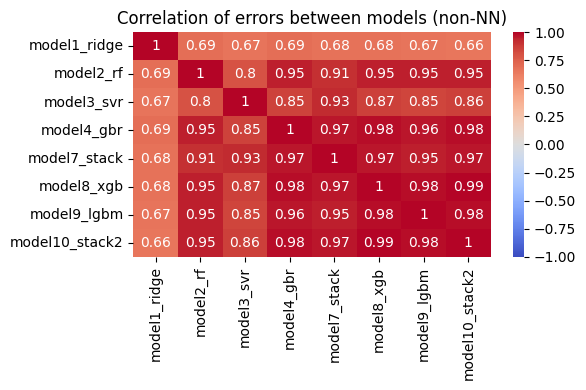

In [ ]:
#Error correlation between non-neural-net models using stored errors

from IPython.display import display
import pandas as pd

error_dict = {}

if "result1" in globals():
    error_dict["model1_ridge"] = result1.errors
if "result2" in globals():
    error_dict["model2_rf"] = result2.errors
if "result3" in globals():
    error_dict["model3_svr"] = result3.errors
if "result4" in globals():
    error_dict["model4_gbr"] = result4.errors
if "result7" in globals():
    error_dict["model7_stack"] = result7.errors
if "result8" in globals():
    error_dict["model8_xgb"] = result8.errors
if "result9" in globals():
    error_dict["model9_lgbm"] = result9.errors
if "result10" in globals():
    error_dict["model10_stack2"] = result10.errors

if not error_dict:
    print("No non-NN result objects with errors found (result1, result2, ...). Run the model cells first.")
else:
    errors_df = pd.DataFrame(error_dict)

    print("First 5 rows of model errors (y_test - y_pred):")
    display(errors_df.head())

    corr_errors = errors_df.corr()
    print("\nCorrelation matrix of model errors:")
    display(corr_errors)

    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_errors, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation of errors between models (non-NN)")
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 0) Same split policy as run_experiment
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1) Define base estimators with names
# Using the FULL pipelines (NOT named_steps["reg"])
estimators = [
    ('gbstack', result10.best_estimator.named_steps["reg"]),
    ('ridge', result1.best_estimator.named_steps["reg"]),
    ('svr', result3.best_estimator.named_steps["reg"]),
]

# 2) Create StackingRegressor with ElasticNet as meta-learner
stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=ElasticNet(random_state=42, max_iter=10_000),
    cv=3,  # 3-fold CV for generating meta-features
    n_jobs=-1
)

# 3) Optionally tune the meta-learner's hyperparameters
# Create param grid with 'final_estimator__' prefix
params_optuna = {
    "final_estimator__alpha": ("float", 1e-6, 1e1, True),
    "final_estimator__l1_ratio": ("float", 0.0, 1.0),
}

result_stack = run_experiment(
    stacking_reg,
    X_train, y_train,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    verbose=1,
    run_full_pipeline=True  # The stacking regressor handles everything
)

best_stacking = result_stack.best_estimator

# 4) Final evaluation on the held-out test split
pred_test = best_stacking.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
mse = mean_squared_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print({"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2})

[I 2026-02-06 18:11:15,425] A new study created in memory with name: no-name-d01729ef-1d94-4cfe-b0ce-990ce08d0224
Best trial: 0. Best value: -0.0657089:   4%|▍         | 1/25 [05:28<2:11:14, 328.09s/it]

[I 2026-02-06 18:16:43,508] Trial 0 finished with value: -0.06570893476636153 and parameters: {'final_estimator__alpha': 4.17266178850166e-06, 'final_estimator__l1_ratio': 0.7135060226705549}. Best is trial 0 with value: -0.06570893476636153.


Best trial: 0. Best value: -0.0657089:   8%|▊         | 2/25 [10:19<1:57:36, 306.79s/it]

[I 2026-02-06 18:21:35,384] Trial 1 finished with value: -0.06570965898541765 and parameters: {'final_estimator__alpha': 3.1824553095022584e-06, 'final_estimator__l1_ratio': 0.47726148868433527}. Best is trial 0 with value: -0.06570893476636153.


Best trial: 0. Best value: -0.0657089:  12%|█▏        | 3/25 [15:16<1:50:45, 302.06s/it]

...

[I 2026-02-06 20:26:56,318] Trial 24 finished with value: -0.06573285529939552 and parameters: {'final_estimator__alpha': 0.00014141997560132018, 'final_estimator__l1_ratio': 0.9123580230176238}. Best is trial 7 with value: -0.06570096279050057.
Best parameters: {'reg__final_estimator__alpha': 6.826792430076074e-05, 'reg__final_estimator__l1_ratio': 0.9371256380657232}
Best CV score (MAE): 0.06570096279050057


C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 0.06241123075715591
RMSE: 0.08344460346707142
MSE: 0.006963001847776788
R^2: 0.8532978177549586


C:\Users\anast\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'MAE': 0.06230792582819115, 'RMSE': 0.08304603806493463, 'MSE': 0.006896644438282572, 'R2': 0.8592030749936611}


### Neural Network

In [28]:
X = X.select_dtypes(include=[np.number, "bool"])

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
X_tr_torch = torch.FloatTensor(X_train_scaled)
y_tr_torch = torch.FloatTensor(y_train.values).unsqueeze(1)
X_te_torch = torch.FloatTensor(X_test_scaled)
y_te_torch = torch.FloatTensor(y_test.values).unsqueeze(1)

In [35]:
train_dataset = TensorDataset(X_tr_torch, y_tr_torch)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [36]:
class Choices13kNet(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=0.0):
        super().__init__()
        layers = []
        dims = [input_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [37]:
input_dim = X_train.shape[1]
model = Choices13kNet(input_dim)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

In [42]:
# Cell 1 — imports + split (same idea as yours)
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import optuna
from sklearn.metrics import mean_absolute_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# Train/val split from training data (don't use test set for tuning)
n_train = len(X_tr_torch)
idx = torch.randperm(n_train, generator=torch.Generator().manual_seed(42))
n_val = int(0.2 * n_train)
val_idx, train_idx = idx[:n_val], idx[n_val:]

X_val_torch = X_tr_torch[val_idx]
y_val_torch = y_tr_torch[val_idx]
X_opt_torch = X_tr_torch[train_idx]
y_opt_torch = y_tr_torch[train_idx]


In [46]:
def _mae_torch(pred: torch.Tensor, y: torch.Tensor) -> float:
    return torch.mean(torch.abs(pred - y)).item()

@torch.no_grad()
def eval_epoch(model, X, y, criterion):
    model.eval()
    Xd, yd = X.to(device), y.to(device)
    pred = model(Xd)
    loss = criterion(pred, yd).item()
    mae = _mae_torch(pred, yd)
    return loss, mae

def train_nn_one_run(
    model,
    train_loader,
    X_val,
    y_val,
    criterion,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose: bool = False,
    log_every: int = 1,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": [],
        "lr": [],
    }

    best_val_mae = float("inf")
    best_epoch = -1
    best_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        running_mae = 0.0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()
            running_mae += _mae_torch(pred.detach(), batch_y)

        train_loss = running_loss / len(train_loader)
        train_mae = running_mae / len(train_loader)

        val_loss, val_mae = eval_epoch(model, X_val, y_val, criterion)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = False
        if val_mae < best_val_mae - 1e-12:
            best_val_mae = val_mae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            is_best = True
        else:
            patience_counter += 1

        # ---- logging ----
        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            tag = " ★" if is_best else ""
            print(
                f"[epoch {epoch:03d}] "
                f"train MAE={train_mae:.5f} | "
                f"val MAE={val_mae:.5f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
                f"{tag}"
            )

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "best_val_mae": best_val_mae,
        "best_epoch": best_epoch,
        "history": history,
    }


In [ ]:
# Cell 3 — Optuna objective (returns +val_mae minimized => direction="minimize")
# Optuna objective with K-fold CV (drop-in pattern)
from sklearn.model_selection import KFold

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    h1 = trial.suggest_categorical("h1", [32, 64, 128, 256])
    h2 = trial.suggest_categorical("h2", [32, 64, 128])
    h3 = trial.suggest_categorical("h3", [16, 32, 64])
    hidden = (h1, h2, h3)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    maes = []

    X = X_tr_torch
    y = y_tr_torch

    for tr_idx, va_idx in kf.split(np.arange(len(X))):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        model = Choices13kNet(input_dim, hidden=hidden, dropout=dropout).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5)
        crit = nn.MSELoss()

        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

        out = train_nn_one_run(model, loader, X_va, y_va, crit, opt, sch, max_epochs=300, patience=40)
        _, va_mae = eval_epoch(model, X_va, y_va, crit)
        maes.append(va_mae)

    return float(np.mean(maes))


optuna.logging.set_verbosity(optuna.logging.WARNING)
study_nn = optuna.create_study(direction="minimize")
study_nn.optimize(objective, n_trials=25, show_progress_bar=True)

print("Best params:", study_nn.best_params, "| Best val MAE:", study_nn.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

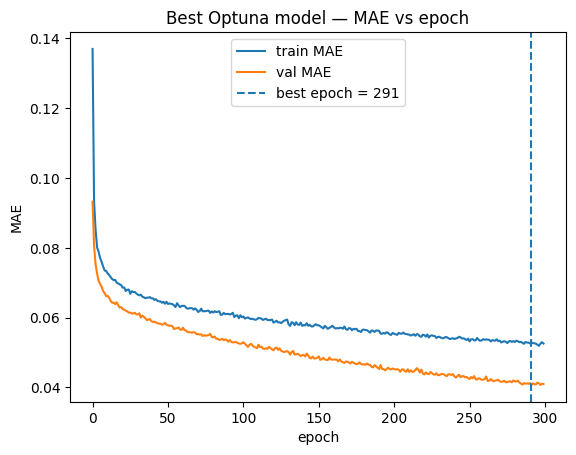

Refit done. Best epoch: 291 | best val MAE: 0.040736 | TEST MAE: 0.062618


In [45]:
# Cell 4 — Refit best model (keep history), plot MAE vs epoch, then test using best epoch
import matplotlib.pyplot as plt

bp = study_nn.best_params
hidden_best = (bp["h1"], bp["h2"], bp["h3"])

model = Choices13kNet(input_dim, hidden=hidden_best, dropout=bp["dropout"]).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=bp["lr"], weight_decay=bp["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

train_loader_full = DataLoader(
    TensorDataset(X_tr_torch, y_tr_torch),
    batch_size=bp["batch_size"],
    shuffle=True,
)

out = train_nn_one_run(
    model=model,
    train_loader=train_loader_full,
    X_val=X_val_torch,
    y_val=y_val_torch,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=300,
    patience=40,
    verbose=True
)

history = out["history"]
best_epoch = out["best_epoch"]
best_val_mae = out["best_val_mae"]

# Plot MAE map (epoch vs MAE) for train/val
epochs = np.arange(len(history["train_mae"]))

plt.figure()
plt.plot(epochs, history["train_mae"], label="train MAE")
plt.plot(epochs, history["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Best Optuna model — MAE vs epoch")
plt.show()

# Test evaluation using best-epoch weights (model already restored)
@torch.no_grad()
def predict(model, X):
    model.eval()
    return model(X.to(device)).detach().cpu().numpy().reshape(-1)

test_pred = predict(model, X_te_torch)
test_mae = mean_absolute_error(y_te_torch.detach().cpu().numpy().reshape(-1), test_pred)

# Save best-epoch weights + metadata
torch.save(
    {
        "state_dict": model.state_dict(),  # already best epoch
        "best_params": bp,
        "best_epoch": best_epoch,
        "best_val_mae": best_val_mae,
        "history": history,
    },
    "best_choices13k_optuna_refit.pt",
)

print(f"Refit done. Best epoch: {best_epoch} | best val MAE: {best_val_mae:.6f} | TEST MAE: {test_mae:.6f}")


In [ ]:
# Cell 1 — imports + build A_list/B_list/y=brate from df_full["a"], df_full["b"], split
import numpy as np
import ast
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

A_col = "a"
B_col = "b"
Y_col = "brate"   # <-- regression target

def parse_lottery_cell(cell):
    """
    cell: list[[p,x],...] OR string like '[[0.8,-5.0],[0.2,10.0]]'
    returns: list[[float p, float x], ...]
    """
    if isinstance(cell, str):
        L = ast.literal_eval(cell)
    else:
        L = cell
    return [[float(px[0]), float(px[1])] for px in L]

A_list = [parse_lottery_cell(v) for v in df_full[A_col].tolist()]
B_list = [parse_lottery_cell(v) for v in df_full[B_col].tolist()]
y = df_full[Y_col].to_numpy(dtype=np.float32).reshape(-1)

# Train/val split
n = len(y)
idx = np.random.RandomState(42).permutation(n)
n_val = int(0.2 * n)
val_idx, train_idx = idx[:n_val], idx[n_val:]

A_tr = [A_list[i] for i in train_idx]
B_tr = [B_list[i] for i in train_idx]
y_tr = y[train_idx]

A_val = [A_list[i] for i in val_idx]
B_val = [B_list[i] for i in val_idx]
y_val = y[val_idx]

print("train:", len(y_tr), "val:", len(y_val))
print("brate stats:", float(y.min()), float(y.mean()), float(y.max()))
print("example A:", A_tr[0])
print("example B:", B_tr[0])

